In [9]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from IPython.display import display

In [16]:
s, w0, Q0, A0 = sp.symbols('s w_0 Q_0 A_0')

Hs = A0 * (1) / (1 + Q0 * (s/ w0 + w0/s))

display('Hs = ', Hs)


z, dt = sp.symbols('z dt')


'Hs = '

A_0/(Q_0*(s/w_0 + w_0/s) + 1)

In [22]:
Hz = Hs.subs({s: (1 - 1/z) / (1 + 1/z) * 2 / dt})
Hz.cancel(z)

(2*A_0*dt*w_0*z**2 - 2*A_0*dt*w_0)/(Q_0*dt**2*w_0**2 + 4*Q_0 - 2*dt*w_0 + z**2*(Q_0*dt**2*w_0**2 + 4*Q_0 + 2*dt*w_0) + z*(2*Q_0*dt**2*w_0**2 - 8*Q_0))

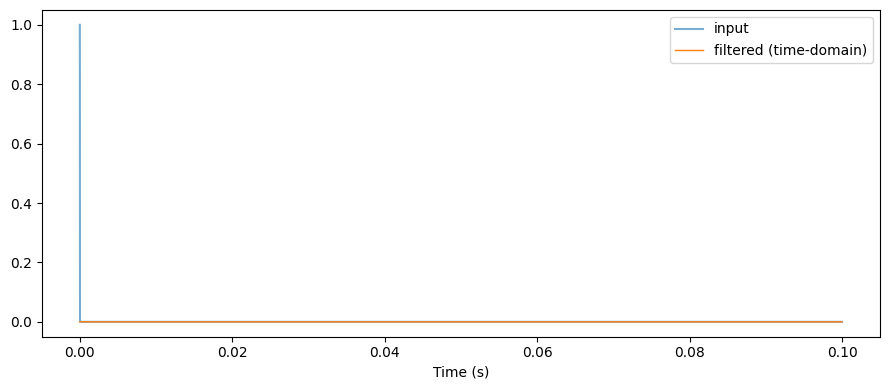

In [ ]:
# Band-pass filter implemented in the time domain (IIR)
# We'll convert the symbolic Hz(z) into numerator/denominator polynomials in z^-1
# extract numeric b,a coefficients and apply a simple lfilter implementation.
# Parameters (set a sensible audio center frequency in Hz)
w0_hz = 1000.0                # center frequency in Hz
w0 = 2 * np.pi * w0_hz    # angular frequency (rad/s)
t60 = 2.0
A0 = 1.0
sr = 44100.0
dt = 1.0 / sr

# damping / Q estimate from your original formula
Q0 = t60 * w0 / (2 * 6.9)

# Rebuild the symbolic discrete Hz (uses Hs defined earlier)
Hz = Hs.subs({s: (1 - 1/z) / (1 + 1/z) * 2 / dt})
Hz = sp.simplify(Hz)

# Substitute numeric parameter values into Hz to get a concrete rational function in z
# The sympy symbols inside Hs were created earlier with names like 'w_0', 'Q_0', 'A_0', 'dt'.
# Create symbol objects that match those names and use them as keys for subs so numeric
# Python variables (w0, Q0, A0, dt) are correctly substituted.
w0_sym, Q0_sym, A0_sym, dt_sym = sp.symbols('w_0 Q_0 A_0 dt')
Hz_num = sp.simplify(Hz.subs({w0_sym: w0, Q0_sym: Q0, A0_sym: A0, dt_sym: dt}))

# Express Hz as a rational function in w = z^-1 (so polynomials will be in w)
w = sp.symbols('w')
Hz_w = sp.simplify(Hz_num.subs(z, 1/w))
num, den = sp.fraction(sp.simplify(sp.together(Hz_w)))

# Get polynomial coefficients (highest power first) and convert to floats
num_poly = sp.Poly(sp.simplify(num), w)
den_poly = sp.Poly(sp.simplify(den), w)
num_coeffs = [float(c.evalf()) for c in num_poly.all_coeffs()]
den_coeffs = [float(c.evalf()) for c in den_poly.all_coeffs()]

# lfilter wants coefficients in increasing powers of z^-1: b = [b0, b1, b2, ...]
# sp.Poly returned coefficients for w^N ... w^0, so reverse the lists
b = list(reversed(num_coeffs))
a = list(reversed(den_coeffs))

# Normalize so that a[0] == 1
a0 = a[0]
b = [bi / a0 for bi in b]
a = [ai / a0 for ai in a]

# Define a simple lfilter (pure numpy) to avoid scipy dependency
def lfilter(b, a, x):
    b = np.array(b)
    a = np.array(a)
    N = len(x)
    y = np.zeros(N)
    for n in range(N):
        acc = 0.0
        # feedforward
        for i in range(len(b)):
            if n - i >= 0:
                acc += b[i] * x[n - i]
        # feedback (skip a[0])
        for j in range(1, len(a)):
            if n - j >= 0:
                acc -= a[j] * y[n - j]
        y[n] = acc
    return y

# Build a short test signal: mixture of sines including the center frequency and others
duration = 0.1
t = np.arange(int(sr * duration)) / sr
x = np.zeros_like(t)
x[0] = 1

# Filter in the time domain
y = lfilter(b, a, x)

# Plot time-domain input and filtered output
plt.figure(figsize=(9, 4))
plt.plot(t, x, label='input', alpha=0.6)
plt.plot(t, y, label='filtered (time-domain)', linewidth=1)
plt.xlabel('Time (s)')
plt.legend()
plt.tight_layout()



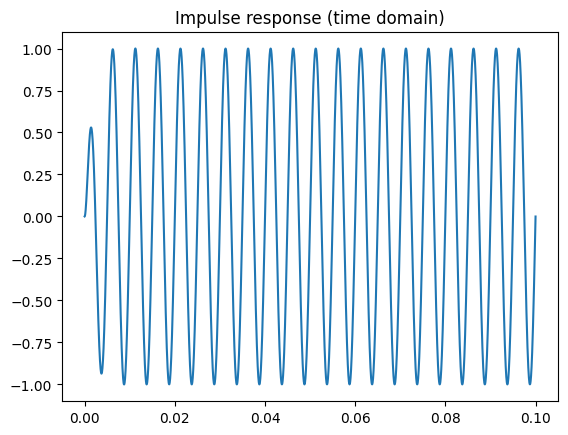

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import bilinear, lfilter, freqs, freqz

# parameters
w0_hz = 200.0
sr = 44100.0
w0 = 2 * np.pi * w0_hz
t60 = 0.01
Q = t60 * w0 / (2 * 6.90775527898)   # use ln(1000) ≈ 6.9078 if t60 relation is desired

# prewarp center frequency
w0_pre = 2 * sr * np.tan(w0 / (2 * sr))

# choose K so that steady-state scaling matches your meaning of A0.
# If you want the amplitude of the resonant sinusoid to be A0 for a unit-steady-state sinusoidal input,
# choose K = A0 (or tune). For an impulse response amplitude you may need to adjust K.
K = 1

# analog bandpass (in s): numerator = K * (w0_pre/Q) * s; denominator s^2 + (w0_pre/Q)*s + w0_pre^2
b_s = [0.0, K * w0_pre / Q, 0.0]
a_s = [1.0, (w0_pre / Q), w0_pre**2]

# bilinear transform -> digital coefficients (normalized for samplerate sr)
b_z, a_z = bilinear(b_s, a_s, fs=sr)

# test impulse
duration = 0.1
N = int(sr * duration)
x = np.zeros(N)
t = np.linspace(0, N / sr, N)
x = np.sin(2 * np.pi * t * w0_hz)

y = lfilter(b_z, a_z, x)

plt.plot(np.arange(N)/sr, y)
plt.title('Impulse response (time domain)')
plt.show()

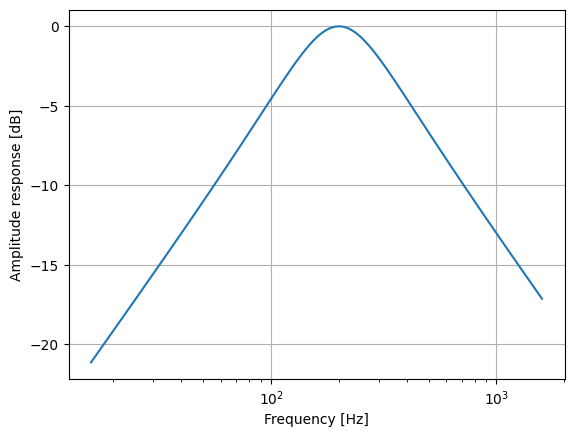

In [94]:
w, h = freqs(b_s, a_s, worN=np.linspace(100, 10000, 10000))

plt.semilogx(w / (2*np.pi), 20 * np.log10(abs(h)))

plt.xlabel('Frequency [Hz]')

plt.ylabel('Amplitude response [dB]')

plt.grid(True)

plt.show()

/var/folders/89/rs78q6rx4qzdmf4yr1ysbys80000gp/T/ipykernel_28082/4285804940.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.semilogx(w, 20 * np.log10(abs(h)))


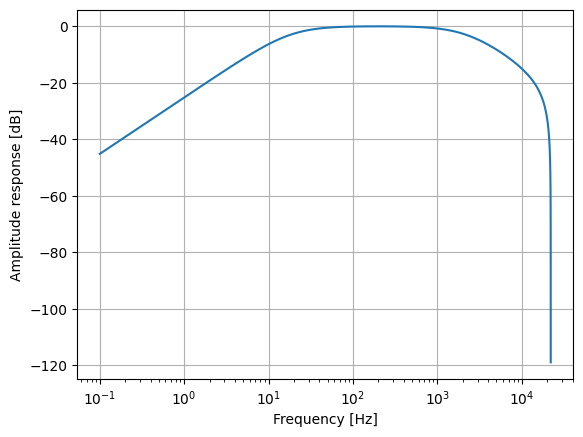

In [92]:
w, h = freqz(b_z, a_z, fs = sr, worN = 220000)

plt.semilogx(w, 20 * np.log10(abs(h)))

plt.xlabel('Frequency [Hz]')

plt.ylabel('Amplitude response [dB]')

plt.grid(True)

plt.show()